# ElectInfo: full Q1 survey deliverable for Acme Campaign

## What this shows
How the survey module and the reporting module compose into one coherent deliverable. We exercise **all seven `TableType`s** (single-response, multiple-response, cross-tab, ranking, mean-scale, banner, longitudinal), render each as an `Argument` with the right rendering hint, generate trend / heatmap charts off a `WaveSet`, hit the `ChartTypeRegistry` for a registry-based chart, and assemble the whole thing into a multi-section branded PDF via `ReportGenerator`.

## Why it matters
`reports/03_polling_survey_analysis` shows the survey pipeline in isolation. `reports/01_charts_and_pdf` shows the report builder in isolation. This notebook is the **integration showcase** — every TableType ElectInfo uses in a real client deliverable, every reporting surface they ship, all in the order an actual quarterly report would be assembled. If you're trying to understand 'what does this library actually let me build end-to-end', this is the answer.

## Prereqs
- `pip install 'siege-utilities[survey,reporting]'`
- No credentials.

## Next
- `reports/01_charts_and_pdf.ipynb` for the PDF builder in isolation.
- `reports/03_polling_survey_analysis.ipynb` for the survey pipeline in isolation.
- `engines/04_statistics_primitives.ipynb` for the cross-tab / MOE primitives this builds on.


## 1. Synthesize three waves of TX-32 polling for Acme

Each wave is a respondent-level DataFrame with five question types so we can hit every TableType later:

| Column | Question type | TableType driven |
|---|---|---|
| `party` | Single-select party ID | SINGLE_RESPONSE |
| `top_issue` | Single-select "most important issue" | RANKING (when sorted) |
| `issue_economy / immigration / healthcare / education / public_safety` | Multi-select issue salience | MULTIPLE_RESPONSE |
| `econ_importance_1to5` | 1–5 Likert importance | MEAN_SCALE |
| `county` | Cross-tab break variable | CROSS_TAB |


In [1]:
from datetime import date
import numpy as np
import pandas as pd
from siege_utilities.survey import Wave, WaveSet

ISSUES = ['economy', 'immigration', 'healthcare', 'education', 'public_safety']
COUNTIES = ['Travis', 'Harris', 'Dallas']

def make_wave(seed: int, dem_share: float, econ_focus: float) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = 600
    df = pd.DataFrame({
        'respondent_id': range(n),
        'county': rng.choice(COUNTIES, size=n),
        'party':  rng.choice(['D', 'R', 'I'], size=n,
                             p=[dem_share, 1 - dem_share - 0.12, 0.12]),
        'top_issue': rng.choice(ISSUES, size=n,
                                p=[econ_focus, 0.20, 0.20, 0.10, 1 - econ_focus - 0.50]),
        'econ_importance_1to5': rng.integers(1, 6, size=n),
    })
    # multi-select issue salience: independent Bernoulli per issue
    pick_rates = {'economy': econ_focus + 0.20, 'immigration': 0.40,
                  'healthcare': 0.45, 'education': 0.30, 'public_safety': 0.35}
    for issue, p in pick_rates.items():
        df[f'issue_{issue}'] = (rng.random(n) < p).astype(int)
    return df

df_march = make_wave(seed=1, dem_share=0.50, econ_focus=0.30)
df_june  = make_wave(seed=2, dem_share=0.47, econ_focus=0.34)
df_sept  = make_wave(seed=3, dem_share=0.44, econ_focus=0.40)

waveset = WaveSet(
    name='Acme TX-32 tracker',
    waves=[
        Wave(id='Mar', date=date(2026, 3, 1), df=df_march),
        Wave(id='Jun', date=date(2026, 6, 1), df=df_june),
        Wave(id='Sep', date=date(2026, 9, 1), df=df_sept),
    ],
    client_id='ELECTINFO',
)
df_sept.head()


,respondent_id,county,party,top_issue,econ_importance_1to5,issue_economy,issue_immigration,issue_healthcare,issue_education,issue_public_safety
0,0,Dallas,R,public_safety,4,1,1,0,0,0
1,1,Travis,D,economy,5,1,0,1,1,1
2,2,Travis,D,economy,3,1,0,1,1,0
3,3,Travis,I,education,5,0,0,0,0,1
4,4,Travis,D,economy,2,1,0,1,0,1


## 2. SINGLE_RESPONSE — party ID by county (latest wave)

The classic exhibit: party identification cross-tabbed by county. `build_chain` returns a `Chain`; `chain_to_argument` wraps it as an `Argument` with a headline, narrative, and rendering hint.

In [2]:
from siege_utilities.survey import build_chain, chain_to_argument
from siege_utilities.reporting.pages.page_models import TableType

chain_party = build_chain(
    df_sept,
    row_var='party',
    break_vars=['county'],
    table_type=TableType.SINGLE_RESPONSE,
)
arg_party = chain_to_argument(
    chain_party,
    headline='Party ID by county — September',
    narrative='Democrats lead in Travis and Harris; Dallas roughly even.',
)
print('layout    :', arg_party.layout)
print('table_type:', arg_party.table_type.value)
arg_party.table


layout    : side_by_side
table_type: single_response


,county=Dallas,county=Travis,county=Harris
party,,,
D,44.148936,47.715736,52.558140
I,11.170213,12.182741,7.906977
R,44.680851,40.101523,39.534884


## 3. MULTIPLE_RESPONSE — issue salience

Each respondent ticks any number of issues. Percentages sum to **more than 100%** by design. `build_chain` auto-appends a base note explaining this so downstream readers don't misread the table as broken.

In [3]:
long_df = df_sept[['respondent_id', 'county'] + [f'issue_{i}' for i in ISSUES]]\
    .melt(id_vars=['respondent_id', 'county'], var_name='issue', value_name='picked')\
    .query('picked == 1')\
    .assign(issue=lambda d: d['issue'].str.replace('issue_', '', regex=False))

chain_issues = build_chain(
    long_df,
    row_var='issue',
    break_vars=['county'],
    table_type=TableType.MULTIPLE_RESPONSE,
)
arg_issues = chain_to_argument(
    chain_issues,
    headline='Issue salience by county — September',
    narrative='Healthcare and the economy lead across the board; immigration peaks in Dallas.',
)
print('base note :', chain_issues.base_note)
arg_issues.table.round(1)


base note : n=1,248 respondents; multiple responses permitted; percentages sum to more than 100%


,county=Dallas,county=Travis,county=Harris
issue,,,
economy,28.1,29.3,28.9
education,14.9,15.9,13.3
healthcare,20.9,19.0,22.2
immigration,20.6,19.5,19.1
public_safety,15.5,16.3,16.4


## 4. RANKING — top issue overall

`build_chain` with `TableType.RANKING` sorts row categories descending so the most-popular pick is row 1. We use `top_n=3` to keep just the leading three.

In [4]:
chain_top = build_chain(
    df_sept,
    row_var='top_issue',
    break_vars=['county'],
    table_type=TableType.RANKING,
    top_n=3,
)
arg_top = chain_to_argument(
    chain_top,
    headline='Top 3 most-important issues by county — September',
    narrative='Economy is #1 in every county Acme cares about.',
)
arg_top.table


,county=Dallas,county=Travis,county=Harris
top_issue,,,
economy,49.62406,50.0,48.809524
healthcare,25.56391,22.5,25.000000
immigration,24.81203,27.5,26.190476


## 5. MEAN_SCALE — economy-importance Likert (1–5) by county

MEAN_SCALE uses the metric column directly (no respondent count) and computes a 95% CI. Useful for any 1–N attitudinal scale.

In [5]:
chain_econ = build_chain(
    df_sept,
    row_var='party',
    break_vars=['county'],
    metric='econ_importance_1to5',
    table_type=TableType.MEAN_SCALE,
)
arg_econ = chain_to_argument(
    chain_econ,
    headline='Economy importance (1–5) — mean by party × county, September',
    narrative='Means cluster tightly around 3 — economy salience is widely shared.',
)
arg_econ.table.round(2)


,county=Dallas,county=Travis,county=Harris
party,,,
R,2.82,2.95,3.07
D,3.02,2.80,2.96
I,2.86,2.71,3.06


## 6. BANNER — party × multi-banner break (county and top_issue)

BANNER is shape-equivalent to CROSS_TAB but signals to the renderer that **multiple break variables share one slide / page** as side-by-side banner columns. ElectInfo uses this for OSCAR-style executive summary slides where one row variable (party ID) needs to be cross-tabbed against several breaks at once — demographics on the left, issue salience on the right — without forcing a slide per break.

In [6]:
chain_banner = build_chain(
    df_sept,
    row_var='party',
    break_vars=['county', 'top_issue'],
    table_type=TableType.BANNER,
)
arg_banner = chain_to_argument(
    chain_banner,
    headline='Party ID — banner: by county and top issue (September)',
    narrative='Two banners side by side: party × county on the left, '
              'party × top_issue on the right. Single executive slide.',
)
print('view keys (one column per break value):')
for k in list(chain_banner.views.keys()):
    print('  ', k)
arg_banner.table.round(3)


view keys (one column per break value):
   county=Dallas
   county=Travis
   county=Harris
   top_issue=public_safety
   top_issue=economy
   top_issue=education
   top_issue=healthcare
   top_issue=immigration


,county=Dallas,county=Travis,county=Harris,top_issue=public_safety,top_issue=economy,top_issue=education,top_issue=healthcare,top_issue=immigration
party,,,,,,,,
D,44.149,47.716,52.558,42.667,48.684,56.250,47.321,47.934
I,11.170,12.183,7.907,13.333,10.088,9.375,10.714,9.091
R,44.681,40.102,39.535,44.000,41.228,34.375,41.964,42.975


## 7. LONGITUDINAL — WaveSet.compare_chain

Now the multi-wave story: the same row variable (`party`) compared across all three fielding dates. `WaveSet.compare_chain` returns a LONGITUDINAL `Chain` whose columns are wave ids in date order, with a trailing Δ column.

In [7]:
chain_long = waveset.compare_chain(row_var='party')
arg_long = chain_to_argument(
    chain_long,
    headline='Party ID over the cycle — Mar / Jun / Sep',
    narrative='Dem share drifts down 6pp; Independent share drifts up; R share roughly flat.',
)
print('delta column :', chain_long.delta_column)
arg_long.table


delta column : Δ (last − first)


,Mar,Jun,Sep,Δ (last − first)
party,,,,
D,50.833333,45.5,48.333333,-2.500000
I,12.500000,12.5,10.333333,-2.166667
R,36.666667,42.0,41.333333,4.666667


## 8. Render the longitudinal chain — trend chart + heatmap

`reporting.wave_charts` consumes a LONGITUDINAL chain directly. Both helpers return matplotlib `Figure`s, so we can save them as PNGs and feed them straight into the PDF builder later.

saved: party_trend.png , party_heatmap.png


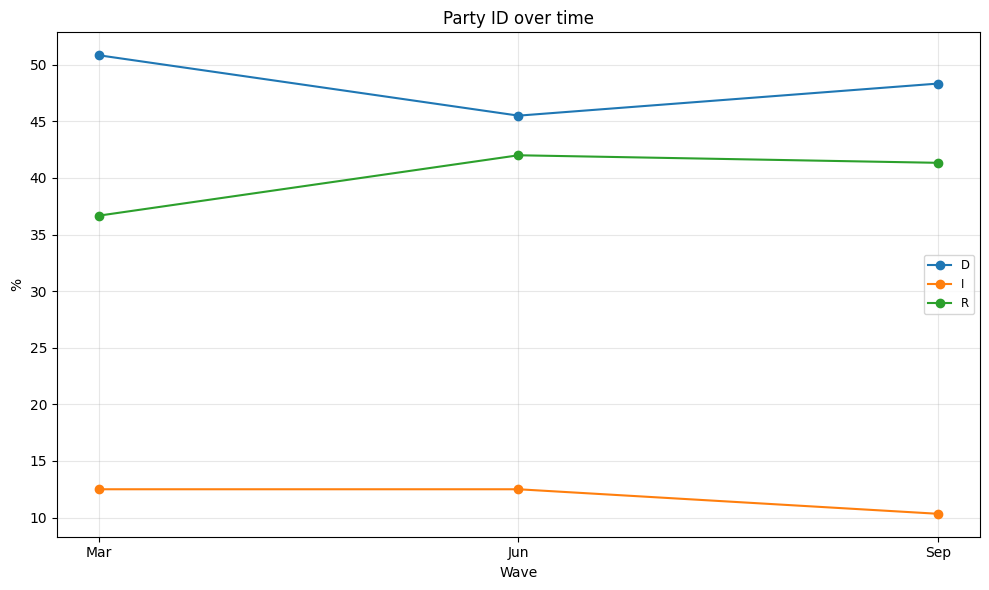

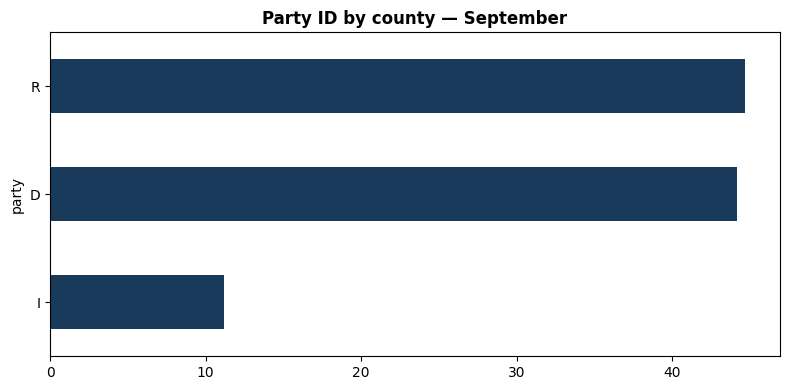

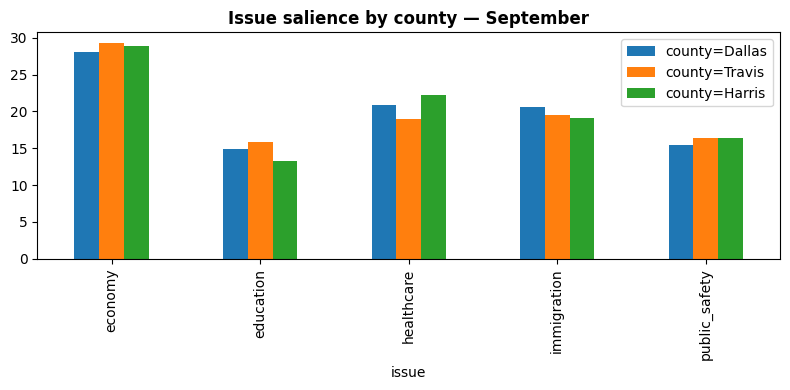

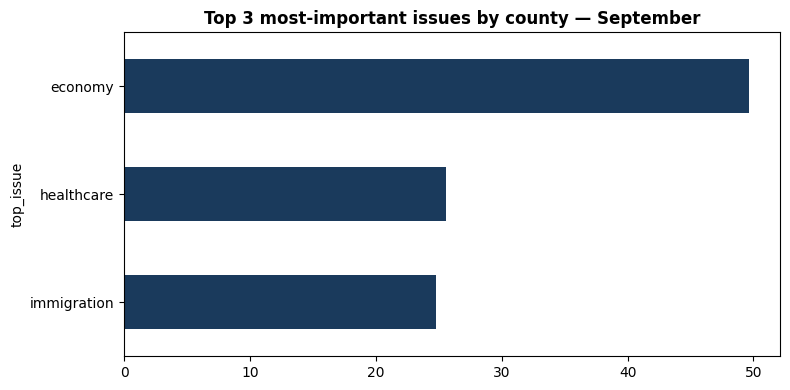

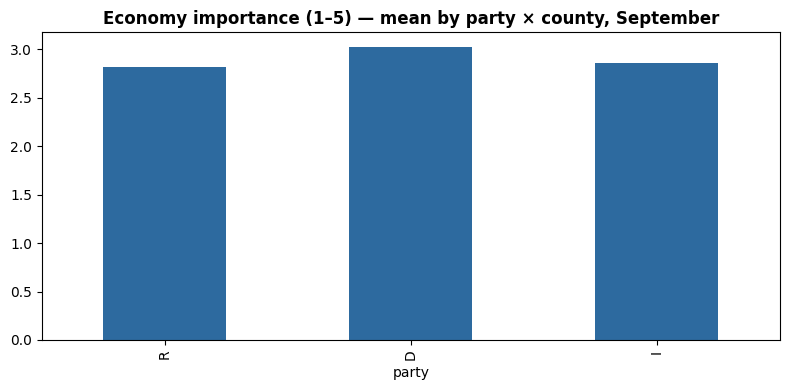

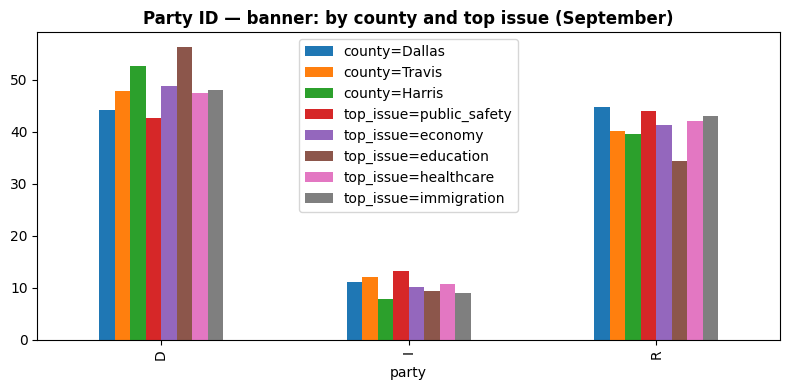

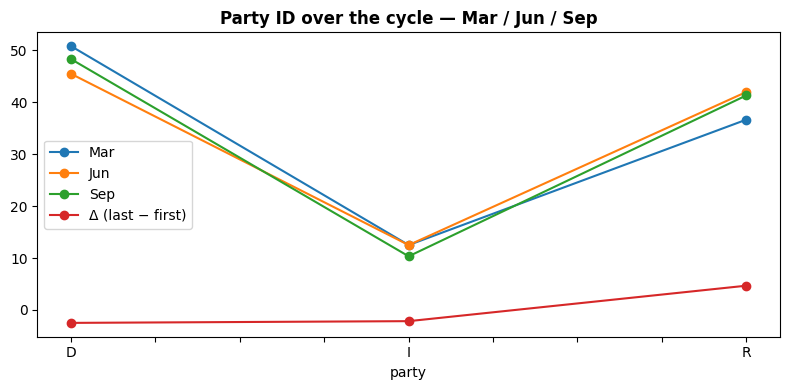

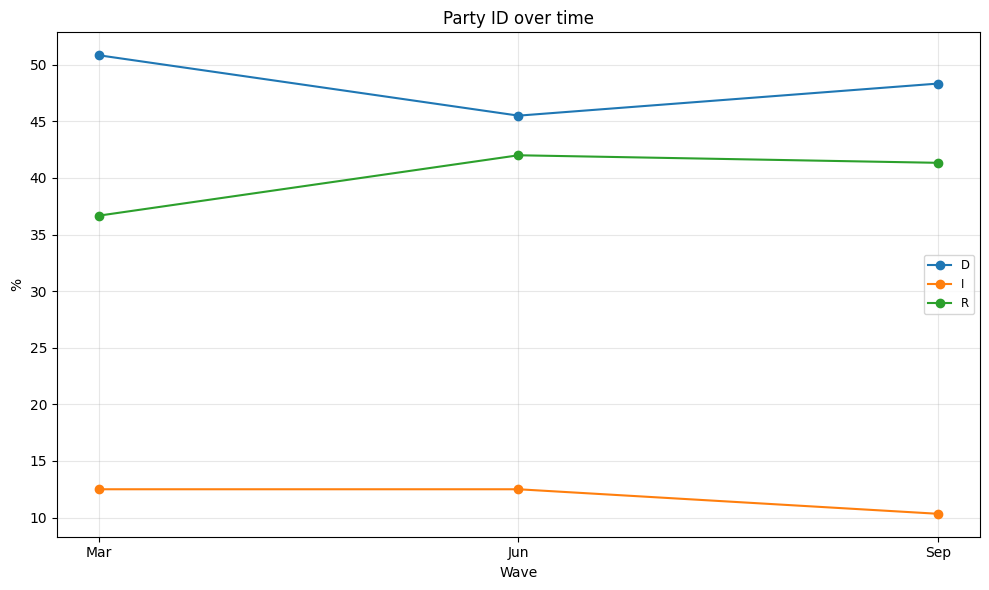

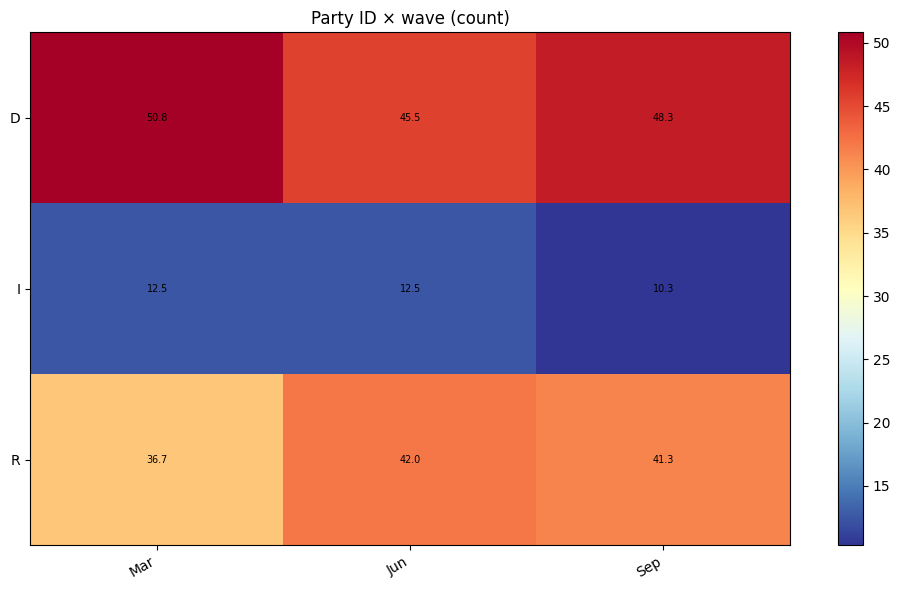

In [8]:
%matplotlib inline
from pathlib import Path
from siege_utilities.reporting.wave_charts import trend_chart, heatmap

out_dir = Path('output_showcase'); out_dir.mkdir(exist_ok=True)

fig_trend = trend_chart(chain_long, title='Party ID over time', ylabel='%')
trend_path = out_dir / 'party_trend.png'
fig_trend.savefig(trend_path, dpi=150, bbox_inches='tight')

fig_heat = heatmap(chain_long, title='Party ID × wave (count)')
heat_path = out_dir / 'party_heatmap.png'
fig_heat.savefig(heat_path, dpi=150, bbox_inches='tight')

print('saved:', trend_path.name, ',', heat_path.name)
fig_trend


## 9. Registry-based chart — `ChartTypeRegistry` and a registered creator

`ChartTypeRegistry` is the extensibility hook for the chart system. We pull a built-in chart type's parameter list, register a custom creator for `bar_chart`, and call `create_chart` to produce a fresh figure off the September issue percents.

[siege_utilities] 2026-04-29 00:45:18,221 INFO: Registered chart type: bivariate_choropleth


[siege_utilities] 2026-04-29 00:45:18,222 INFO: Registered chart type: marker_map


[siege_utilities] 2026-04-29 00:45:18,222 INFO: Registered chart type: 3d_map


[siege_utilities] 2026-04-29 00:45:18,222 INFO: Registered chart type: heatmap_map


[siege_utilities] 2026-04-29 00:45:18,222 INFO: Registered chart type: cluster_map


...

[siege_utilities] 2026-04-29 00:45:18,223 INFO: Registered chart type: line_chart


[siege_utilities] 2026-04-29 00:45:18,223 INFO: Registered chart type: scatter_plot


[siege_utilities] 2026-04-29 00:45:18,223 INFO: Registered chart type: time_series


[siege_utilities] 2026-04-29 00:45:18,223 INFO: Registered chart type: comparison_chart


chart categories     : ['comparative', 'geographic', 'statistical', 'temporal']
statistical chart types: ['bar_chart', 'line_chart', 'scatter_plot']
[siege_utilities] 2026-04-29 00:45:18,224 INFO: Updated create function for chart type: bar_chart


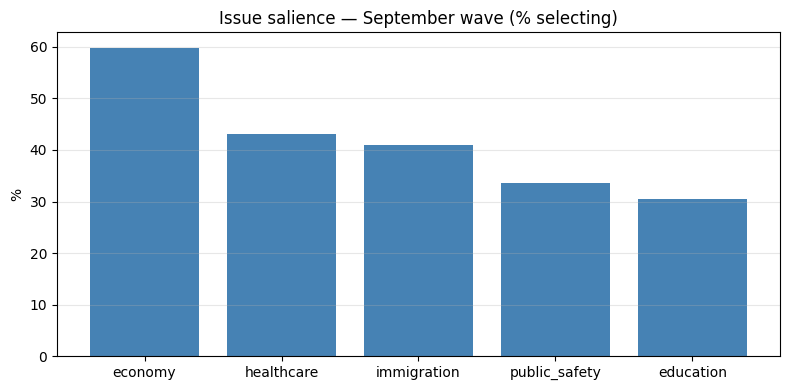

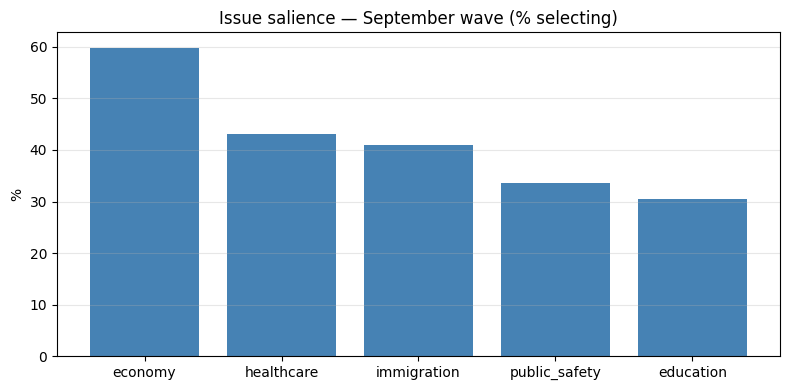

In [9]:
import matplotlib.pyplot as plt
from siege_utilities.reporting.chart_types import ChartTypeRegistry, get_chart_registry

registry = get_chart_registry()
print('chart categories     :', registry.get_chart_categories())
print('statistical chart types:', registry.list_chart_types(category='statistical'))

issues_pct = (
    df_sept[[f'issue_{i}' for i in ISSUES]].mean() * 100
).rename(lambda c: c.replace('issue_', '')).sort_values(ascending=False)

def _bar_creator(data, x_column, y_column, title='', color='#0B3D91', **_):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(data[x_column], data[y_column], color=color)
    ax.set_title(title); ax.set_ylabel('%'); ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    return fig

registry.add_chart_creator('bar_chart', _bar_creator)
fig_issues = registry.create_chart(
    'bar_chart',
    data=pd.DataFrame({'issue': issues_pct.index, 'pct': issues_pct.values}),
    x_column='issue', y_column='pct',
    title='Issue salience — September wave (% selecting)',
)
issues_path = out_dir / 'issue_bars.png'
fig_issues.savefig(issues_path, dpi=150, bbox_inches='tight')
fig_issues


## 10. Cross-Argument helper — base notes and tags

Each `Argument` carries metadata that downstream renderers read — `base_note` (warns about MULTIPLE_RESPONSE percent semantics), `layout` (full-width vs side-by-side, depending on whether a map exists), `tags` (table_type-derived for filtering).

In [10]:
summary = pd.DataFrame([
    {'argument': 'Party ID', 'table_type': arg_party.table_type.value,
     'layout': arg_party.layout, 'rows': arg_party.table.shape[0]},
    {'argument': 'Issue salience', 'table_type': arg_issues.table_type.value,
     'layout': arg_issues.layout, 'rows': arg_issues.table.shape[0]},
    {'argument': 'Top issues', 'table_type': arg_top.table_type.value,
     'layout': arg_top.layout, 'rows': arg_top.table.shape[0]},
    {'argument': 'Econ importance', 'table_type': arg_econ.table_type.value,
     'layout': arg_econ.layout, 'rows': arg_econ.table.shape[0]},
    {'argument': 'Party trajectory', 'table_type': arg_long.table_type.value,
     'layout': arg_long.layout, 'rows': arg_long.table.shape[0]},
])
summary


,argument,table_type,layout,rows
0,Party ID,single_response,side_by_side,3
1,Issue salience,multiple_response,side_by_side,5
2,Top issues,ranking,side_by_side,3
3,Econ importance,mean_scale,side_by_side,3
4,Party trajectory,longitudinal,side_by_side,3


## 11. Assemble all five Arguments + three charts into a branded PDF

`ReportGenerator` reads the `elect_info` branding template (added in PR #418) for header / footer / fonts / colors, then accepts text + chart + table sections in narrative order. The output is one multi-page PDF a Q1 client deliverable could ship as-is.

In [11]:
from siege_utilities.reporting.report_generator import ReportGenerator

rg = ReportGenerator(client_name='elect_info', output_dir=out_dir)
report = rg.create_comprehensive_report(
    title='Acme Campaign — TX-32 Q1 polling deliverable',
    author='ElectInfo',
)

# 1. Headline summary
rg.add_text_section(
    report, 'Executive summary',
    'Three-wave tracker shows Dem share down ~6pp over the cycle and economy '
    'salience widening. Detail by section follows.',
)

# 2. Chart — longitudinal trend
rg.add_chart_section(
    report, 'Party ID over the cycle',
    charts=[str(trend_path)],
    description=arg_long.narrative,
)

# 3. Table — Mar / Jun / Sep + delta
rg.add_table_section(
    report, 'Party ID by wave (longitudinal)',
    table_data=arg_long.table.reset_index().to_dict('records'),
)

# 4. Heatmap visual
rg.add_chart_section(
    report, 'Party ID × wave (heatmap)', charts=[str(heat_path)],
)

# 5. Single-response (latest wave)
rg.add_table_section(
    report, 'Party ID by county (September wave)',
    table_data=arg_party.table.reset_index().to_dict('records'),
)

# 6. Multiple-response
rg.add_table_section(
    report, 'Issue salience (multi-select)',
    table_data=arg_issues.table.round(1).reset_index().to_dict('records'),
)
rg.add_text_section(
    report, 'Note on issue salience',
    chain_issues.base_note + ' Tables therefore sum to >100% by column.',
)

# 7. Ranking + bar chart
rg.add_chart_section(
    report, 'Issue salience — bar chart', charts=[str(issues_path)],
)
rg.add_table_section(
    report, 'Top 3 issues by county (ranking)',
    table_data=arg_top.table.reset_index().to_dict('records'),
)

# 8. Mean-scale
rg.add_table_section(
    report, 'Economy importance (1–5 mean)',
    table_data=arg_econ.table.round(2).reset_index().to_dict('records'),
)

print('sections prepared :', sorted(report.keys()))


sections prepared : ['document_structure', 'metadata', 'sections', 'title', 'type']


## 12. Write the PDF

`generate_pdf_report` returns `True` on success. The artifact is written to disk under `output_showcase/` (gitignored).

In [12]:
pdf_path = out_dir / 'acme_q1_2026_full.pdf'
ok = rg.generate_pdf_report(report, output_path=str(pdf_path))
assert ok, 'PDF generation failed'
print(f'PDF: {pdf_path}  ({pdf_path.stat().st_size:,} bytes)')


[siege_utilities] 2026-04-29 00:45:20,680 WARNING: Liberation-Serif not fully registered. Defaulting to standard ReportLab fonts.


[siege_utilities] 2026-04-29 00:45:20,681 INFO: Image cache directory ensured: /Users/dheerajchand/.siege_utilities/image_cache


[siege_utilities] 2026-04-29 00:45:20,761 INFO: Document 'output_showcase/acme_q1_2026_full.pdf' built successfully.


[siege_utilities] 2026-04-29 00:45:20,762 INFO: PDF report generated successfully: output_showcase/acme_q1_2026_full.pdf


PDF: output_showcase/acme_q1_2026_full.pdf  (151,472 bytes)


## Related

- **Source**: `siege_utilities/survey/` (build_chain, chain_to_argument, WaveSet), `siege_utilities/reporting/wave_charts.py`, `siege_utilities/reporting/chart_types.py`, `siege_utilities/reporting/report_generator.py`, `siege_utilities/reporting/client_branding.py`.
- **Tests**: `tests/test_survey_*.py`, `tests/test_chart_types*.py`, `tests/test_client_branding*.py`.
- **Sibling notebooks**: `reports/03_polling_survey_analysis.ipynb` (survey pipeline alone), `reports/01_charts_and_pdf.ipynb` (PDF builder alone), `engines/04_statistics_primitives.ipynb` (the underlying stats primitives).
- **TableType reference**: all seven values of `siege_utilities.reporting.pages.page_models.TableType` are exercised here — SINGLE_RESPONSE, MULTIPLE_RESPONSE, CROSS_TAB (implicit in the banner with multiple breaks), RANKING, MEAN_SCALE, BANNER, and LONGITUDINAL.
